# Library Examples

## Archiving information

In [2]:
from datetime import datetime, timedelta

import polars as pl
from pytz import UTC

from epicsarchiver import ArchiverAppliance

%matplotlib inline

In [3]:
archiver = ArchiverAppliance("archiver-linac-04.tn.esss.lu.se")
pv = "DTL-010:EMR-TT-001:Temp"

## Getting Data

In [6]:
_, events = archiver.get_events(pv, datetime.now(tz=UTC) - timedelta(seconds=1), datetime.now(tz=UTC))
events

[ArchiveEvent(pv='DTL-010:EMR-TT-001:Temp', val=28.43, secondsintoyear=8947889, year=2026, nanos=813585251, severity=1, status=4, field_values=[]),
 ArchiveEvent(pv='DTL-010:EMR-TT-001:Temp', val=28.39, secondsintoyear=8947896, year=2026, nanos=203578672, severity=1, status=4, field_values=[]),
 ArchiveEvent(pv='DTL-010:EMR-TT-001:Temp', val=28.44, secondsintoyear=8947896, year=2026, nanos=343582919, severity=1, status=4, field_values=[]),
 ArchiveEvent(pv='DTL-010:EMR-TT-001:Temp', val=28.41, secondsintoyear=8947896, year=2026, nanos=393577176, severity=1, status=4, field_values=[]),
 ArchiveEvent(pv='DTL-010:EMR-TT-001:Temp', val=28.44, secondsintoyear=8947896, year=2026, nanos=813582644, severity=1, status=4, field_values=[]),
 ArchiveEvent(pv='DTL-010:EMR-TT-001:Temp', val=28.39, secondsintoyear=8947896, year=2026, nanos=903576790, severity=1, status=4, field_values=[]),
 ArchiveEvent(pv='DTL-010:EMR-TT-001:Temp', val=28.43, secondsintoyear=8947896, year=2026, nanos=953581553, seve

In [7]:
df = archiver.get_data(pv, datetime.now(tz=UTC) - timedelta(seconds=30), datetime.now(tz=UTC))

In [8]:
df.head()

date,val,severity,status,field_values,headers
"datetime[ns, UTC]",f64,i32,i32,list[struct[2]],list[struct[2]]
2026-04-14 13:31:08.003958132 UTC,28.43,1,4,[],"[{""EGU"",""degC""}, {""PREC"",""0""}]"
2026-04-14 13:31:08.193574887 UTC,28.4,1,4,[],"[{""EGU"",""degC""}, {""PREC"",""0""}]"
2026-04-14 13:31:08.473577535 UTC,28.43,1,4,[],"[{""EGU"",""degC""}, {""PREC"",""0""}]"
2026-04-14 13:31:08.523595614 UTC,28.39,1,4,[],"[{""EGU"",""degC""}, {""PREC"",""0""}]"
2026-04-14 13:31:08.563582445 UTC,28.43,1,4,[],"[{""EGU"",""degC""}, {""PREC"",""0""}]"


## Async Fetch Data

In [9]:
from epicsarchiver.retrieval.archiver_retrieval.async_archiver_retrieval import AsyncArchiverRetrieval
from pytz import timezone

In [10]:
tz = timezone("Europe/Stockholm")

In [11]:
async with AsyncArchiverRetrieval(archiver.hostname) as a_archiver:
    print(await a_archiver.get_events(pv, datetime.now(tz=tz) - timedelta(microseconds=100), datetime.now(tz=tz)))

[ArchiveEvent(pv='DTL-010:EMR-TT-001:Temp', val=28.43, secondsintoyear=8947899, year=2026, nanos=753570124, severity=1, status=4, field_values=[])]


In [12]:
async with AsyncArchiverRetrieval(archiver.hostname) as a_archiver:
    print(await a_archiver.get_all_events([pv, "DTL-020:EMR-TT-001:Temp", "DTL-030:EMR-TT-001:Temp"], datetime.now(tz=tz) - timedelta(microseconds=100), datetime.now(tz=tz)))

{'DTL-010:EMR-TT-001:Temp': [ArchiveEvent(pv='DTL-010:EMR-TT-001:Temp', val=28.43, secondsintoyear=8947899, year=2026, nanos=753570124, severity=1, status=4, field_values=[])], 'DTL-020:EMR-TT-001:Temp': [ArchiveEvent(pv='DTL-020:EMR-TT-001:Temp', val=28.61, secondsintoyear=8947899, year=2026, nanos=673792496, severity=1, status=4, field_values=[])], 'DTL-030:EMR-TT-001:Temp': [ArchiveEvent(pv='DTL-030:EMR-TT-001:Temp', val=28.67, secondsintoyear=8947897, year=2026, nanos=264509701, severity=1, status=4, field_values=[])]}


## Displaying and Calculating Summaries

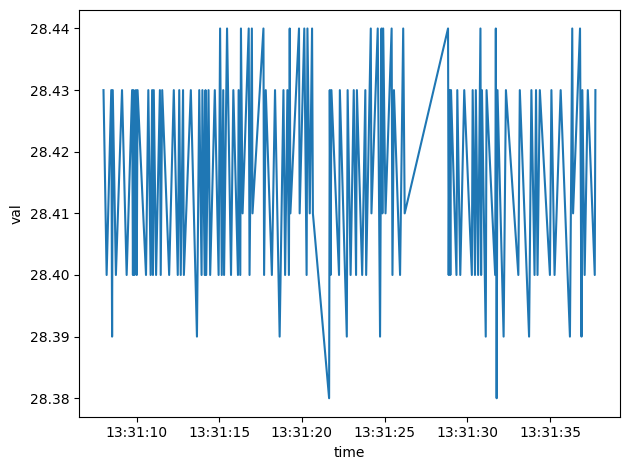

In [13]:
import matplotlib.pyplot as plt

plt.plot(df["date"], df["val"])
plt.xlabel("time")
plt.ylabel("val")
plt.tight_layout()
# NBVAL_IGNORE_OUTPUT

In [15]:
from epicsarchiver.retrieval.archiver_retrieval.processor import Processor, ProcessorName

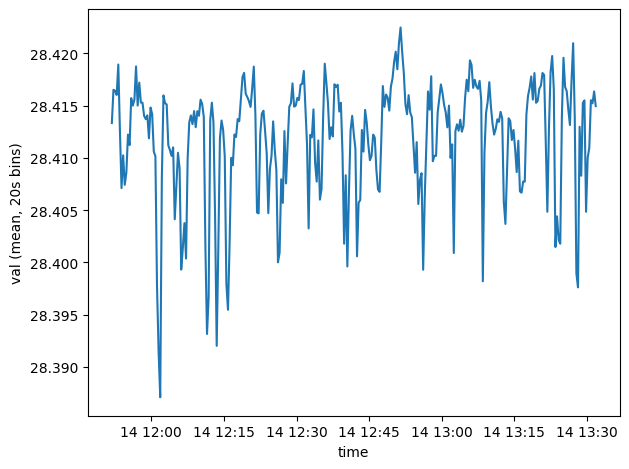

In [16]:
df_mean = archiver.get_data(
    pv,
    datetime.now(tz=UTC) - timedelta(seconds=6000),
    datetime.now(tz=UTC),
    Processor(ProcessorName.MEAN, 20),
)
plt.plot(df_mean["date"], df_mean["val"])
plt.xlabel("time")
plt.ylabel("val (mean, 20s bins)")
plt.tight_layout()
# NBVAL_IGNORE_OUTPUT